1. Write a function to calculate and return the Euclidean distance between
two vectors. [2 pts]

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # You will need this for the pair plots later
import math

def euclidean_distance(vec1, vec2):
    """
    Input:
        vec1, vec2: numeric vectors (NumPy arrays) of equal length
    Output:
        dist: Euclidean distance between vec1 and vec2 
    """
    # your code
    # Calculate the L2 norm of the difference between the vectors
    dist = np.linalg.norm(vec1 - vec2)
    return dist

2. Write a function to calculate and return the Manhattan distance between
two vectors. [2 pts]


In [4]:
def manhattan_distance(vec1, vec2):
    """
    Input:
        vec1, vec2: 2 vectors  (NumPy arrays)  
    Output:
        dist: Manhattan distance between vec1 and vec2 
    """
    # your code
    # Sum of the absolute differences
    dist = np.sum(np.abs(vec1 - vec2))
    return dist

3. Write a function to calculate and return the accuracy and generalization
error of two vectors. [4 pts]

In [5]:
def accuracy_and_error(y_true, y_pred):
    """
    Input:
        y_true: true labels 
        y_pred: predicted labels
    Output:
        accuracy: proportion of correct predictions 
        gen_error: generalization error = 1 - accuracy 
    """
    # your code
    # Calculate accuracy by checking where predictions match true labels
    accuracy = np.mean(y_true == y_pred)
    gen_error = 1 - accuracy
    
    return accuracy, gen_error

4. Write three functions to compute precision, recall, and F1 score. [6 pts]


In [6]:
def precision_score(y_true, y_pred):
    """
    Input:
        y_true: true binary labels
        y_pred: predicted binary labels
    Output:
        precision: precision score (float)
    """
    # your code
    #Finding True positive and False positive
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    
    #Checking for division by zero error
    if (tp + fp) == 0:
        return 0.0
        
    precision = tp / (tp + fp)
    return precision


def recall_score(y_true, y_pred):
    """
    Input:
        y_true: true binary labels
        y_pred: predicted binary labels
    Output:
        recall: recall score (float)
    """
    # your code
    #Finding the True Positive and False Negative
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    #Checking for division by zero error
    if (tp + fn) == 0:
        return 0.0
        
    recall = tp / (tp + fn)
    return recall


def f1_score(y_true, y_pred):
    """
    Input:
        y_true: true binary labels
        y_pred: predicted binary labels
    Output:
        f1: F1 score (float)
    """
    # your code
    #Finding Precision and recall by previously defined functions
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    #Checking for division by zero error
    if (precision + recall) == 0:
        return 0.0
    
    f1 = 2 * (precision * recall) / (precision + recall)
    return f1


5. Write a function to compute the confusion matrix of two vectors. [4 pts]

In [7]:
def confusion_matrix(y_true, y_pred):
    """
    Input:
        y_true: true binary labels
        y_pred: predicted binary labels
    Output:
        cm: 2x2 confusion matrix (e.g., [[TN, FP], [FN, TP]])
    """
    # your code
    # True Negatives: True is 0, Predicted is 0
    tn = np.sum((y_true == 0) & (y_pred == 0))
    
    # False Positives: True is 0, Predicted is 1
    fp = np.sum((y_true == 0) & (y_pred == 1))
    
    # False Negatives: True is 1, Predicted is 0
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    # True Positives: True is 1, Predicted is 1
    tp = np.sum((y_true == 1) & (y_pred == 1))
    cm = np.array([[tn, fp], [fn, tp]])
    return cm


6. Write a function to generate the Receiver Operating Characteristic (ROC)
curve. [8 pts]


In [8]:
def roc_curve(y_true, y_score):
    """
    Input:
        y_true: array-like of shape (n,), true binary labels (0/1)
        y_score: array-like of shape (n,), predicted scores/probabilities in [0, 1]
    Output:
        fpr: array of false positive rates, in increasing threshold order
        tpr: array of true positive rates, in increasing threshold order
        thresholds: array of thresholds used to compute the curve
    """
    # your code
    y_true = np.array(y_true)
    y_score = np.array(y_score)

    #Sort scores and corresponding truth values in descending order
    # We use stable sort (mergesort) to preserve original order of ties if significant
    desc_score_indices = np.argsort(y_score, kind="mergesort")[::-1]
    y_score = y_score[desc_score_indices]
    y_true = y_true[desc_score_indices]

    # Identify indices where the score changes (threshold transitions)
    # np.diff gives non-zero values where adjacent elements differ.
    # We append the last index to ensure the final point (all positives) is included.
    distinct_value_indices = np.where(np.diff(y_score))[0]
    threshold_idxs = np.r_[distinct_value_indices, y_true.size - 1]

    # 3. Calculate Cumulative Sums (TPs and FPs) at each threshold
    # The cumsum at index `i` is the count of positives/negatives 
    # if we set the threshold at y_score[i] (inclusive)
    tps = np.cumsum(y_true)[threshold_idxs]
    fps = np.cumsum(1 - y_true)[threshold_idxs]

    # Calculate Rates
    # Total actual positives (P) and negatives (N)
    P = np.sum(y_true)
    N = len(y_true) - P
    
    # Handle edge case: if dataset has no positives or no negatives
    if P == 0: P = 1 
    if N == 0: N = 1 

    tpr = tps / P
    fpr = fps / N
    
    # Add the start point (0, 0)
    # Standard convention: use a threshold slightly higher than the max score
    # to represent the state where no samples are classified as positive.
    tpr = np.r_[0, tpr]
    fpr = np.r_[0, fpr]
    thresholds = np.r_[y_score[0] + 1, y_score[threshold_idxs]]
    return fpr, tpr, thresholds

def Plot_RocCurve(fpr, tpr, label = None):
    plt.style.use('ggplot')
    plt.plot(fpr, tpr, color='r', linewidth=5, label=label) 
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.axis([0, 1, 0, 1])
    plt.title('ROC Curve ')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    
    return plt.show()


7. Write a function to compute the area under the curve (AUC) for the ROC
curve. [4 pts]


In [9]:
def auc_roc(y_true, y_score):
    """
    Input:
        y_true: array-like of shape (n,), true binary labels (0/1)
        y_score: array-like of shape (n,), predicted scores/probabilities in [0, 1]
    Output:
        auc: area under the ROC curve (float)
    """
    # your code
    y_true = np.array(y_true)
    y_score = np.array(y_score)

    # Sort by score (descending)
    # We use stable sort to ensure consistent behavior for ties, though
    # the trapezoidal rule handles the area correctly regardless.
    desc_score_indices = np.argsort(y_score, kind="mergesort")[::-1]
    y_true = y_true[desc_score_indices]
    y_score = y_score[desc_score_indices]

    # Identify indices where the score changes
    # These are the "knots" of the curve.
    distinct_value_indices = np.where(np.diff(y_score))[0]
    threshold_idxs = np.r_[distinct_value_indices, y_true.size - 1]

    # Calculate Cumulative Sums (TPs and FPs) at each threshold
    tps = np.cumsum(y_true)[threshold_idxs]
    fps = np.cumsum(1 - y_true)[threshold_idxs]

    # Convert to Rates (TPR and FPR)
    # Add (0, 0) as the starting point
    tpr = np.r_[0, tps / tps[-1]]
    fpr = np.r_[0, fps / fps[-1]]

    # Compute Area using the Trapezoidal Rule
    # Area = sum of (width * average_height) for each segment
    auc = np.trapz(tpr, fpr)
    return auc


8. Write a function to generate the precision-recall curve. [10 pts]


In [10]:
def precision_recall_curve(y_true, y_score):
    """
    Input:
        y_true: array-like of shape (n,), true binary labels (0/1)
        y_score: array-like of shape (n,), predicted scores/probabilities in [0, 1]
    Output:
        precision: array of precision values
        recall: array of recall values
        thresholds: array of thresholds used to compute the curve
    """
    # your code
    y_true = np.array(y_true)
    y_score = np.array(y_score)

    # Sort scores in descending order
    
    desc_score_indices = np.argsort(y_score, kind="mergesort")[::-1]
    y_score = y_score[desc_score_indices]
    y_true = y_true[desc_score_indices]

    # Identify indices where the score changes (the "knots" of the curve)
    # np.diff gives non-zero values where adjacent elements differ.
    
    distinct_value_indices = np.where(np.diff(y_score))[0]
    threshold_idxs = np.r_[distinct_value_indices, y_true.size - 1]

    # Calculate Cumulative Sums (TPs and FPs) at each threshold
    # tps[i] = Number of True Positives if we set threshold at y_score[i] 
    tps = np.cumsum(y_true)[threshold_idxs]
    
    # fps[i] = Number of False Positives if we set threshold at y_score[i] 
    fps = np.cumsum(1 - y_true)[threshold_idxs]

    # Calculate Precision and Recall
    # Precision = TP / (TP + FP)
    # Recall = TP / Total Positives
    
    precision = tps / (tps + fps)
    
    # Handle edge case where Total Positives is 0
    total_positives = np.sum(y_true)
    if total_positives == 0:
        recall = np.zeros_like(tps, dtype=float)
    else:
        recall = tps / total_positives

    # Append the final point (Threshold = infinity)
    # Standard convention: Precision=1, Recall=0 at the highest threshold
    precision = np.r_[precision, 1.0]
    recall = np.r_[recall, 0.0]
    
    # Thresholds typically don't include the artificial 'infinity' point
    thresholds = y_score[threshold_idxs]
    return precision, recall, thresholds

def plot_PrecisionRecallCurve(precision, recall, thresholds):        
    plt.style.use('ggplot')
    plt.plot(thresholds, precision, "b--",  linewidth=8, label="Precision") 
    plt.plot(thresholds, recall, "g-",  linewidth=3, label="Recall") 
    plt.xlabel("Threshold")
    plt.legend(loc="lower right")
    plt.title('Precision-Recall Curve')
    plt.ylim([0, 1.1])    
    
    return plt.show()


```
9. Implement a KNN Classifier model class with the following three methods: [20 pts]
    (a) fit(self, X, Y, n neighbors, weights=’uniform’, distance=’euclidean’,
    method=’predict’): This method stores the relevant values as instance variables.
    • Arguments:
        – X: ndarray, a numpy array with rows representing data samples and columns representing features.
        – Y: ndarray, a 1D numpy array with labels corresponding to
        each row of the feature matrix X.
        – n neighbors: int, the number of nearest neighbors.
        – weights: string, optional (default = ’uniform’), the weight
        function used in prediction. Possible values:
            ∗ ‘uniform’: uniform weights. All points in each neighborhood are weighted equally.
            ∗ ‘distance’: weight points by the inverse of their distance,
            so closer neighbors have a greater influence.
        – distance: str: optional (default = ’euclidean’) – The distance metric used for computing similarity:
            ∗ ‘euclidean’:Uses the L2 norm (Euclidean distance).
            ∗ ‘manhattan’:Uses the L1 norm (Manhattan distance).
        – method: str: optional (default = ’predict’), specifies the
        output type:
            ∗ ’predict’:Returns class labels.
            ∗ ‘predict proba’:Returns class probabilities.
            • Returns: No return value necessary.
    (b) predict(self, X): This method uses the instance variables stored
    by the fit method.
    • Arguments:
        – X: ndarray, a numpy array containing samples for prediction,
        with rows representing data samples and columns representing features.
        • Returns: 1D array of predictions for each row in X, designed as
        a column vector.
    (c) init (self): Standard Python initialization function to instantiate the class; just ”pass” this.
    

In [11]:

class KNN_Classifier:
    def __init__(self):
        # We don't need to initialize anything special here, so just pass
        pass

    def fit(self, X, Y, n_neighbors, weights='uniform', distance='euclidean', method='predict'):
        # Save all the data and settings so we can use them later to make predictions
        self.X_train = X               
        self.Y_train = Y               
        self.n_neighbors = n_neighbors 
        self.weights = weights         
        self.distance = distance       
        self.method = method           

    def predict(self, X):
        predictions = []
        
        # Go through our new test data one row at a time
        for x_test in X:
            distances = []
            
            # 1. Measure the distance between this test point and every single training point
            for x_train in self.X_train:
                if self.distance == 'euclidean':
                    # Call the custom Euclidean function you made in Question 1
                    dist = euclidean_distance(x_test, x_train)
                elif self.distance == 'manhattan':
                    # Call the custom Manhattan function you made in Question 2
                    dist = manhattan_distance(x_test, x_train)
                
                distances.append(dist)
                
            distances = np.array(distances)
            
            # 2. Sort the distances to find the indices of our 'k' closest neighbors
            nearest_indices = np.argsort(distances)[:self.n_neighbors]
            
            # 3. Grab the actual labels and distances for those closest neighbors
            nearest_labels = self.Y_train[nearest_indices]
            nearest_distances = distances[nearest_indices]
            
            # 4. Figure out the final vote based on our chosen weighting rule
            if self.weights == 'uniform':
                # Everyone gets an equal vote. Find the most common label.
                values, counts = np.unique(nearest_labels, return_counts=True)
                pred_label = values[np.argmax(counts)]
                
                # Calculate the simple probability for class 1
                prob_class_1 = np.sum(nearest_labels == 1) / self.n_neighbors
                
            elif self.weights == 'distance':
                # Closer neighbors get a stronger vote. 
                # We add 1e-5 to avoid a crash if the distance is exactly zero.
                inverse_distances = 1.0 / (nearest_distances + 1e-5)
                
                # Tally up the weighted votes for each class
                classes = np.unique(self.Y_train)
                weighted_votes = np.zeros(len(classes))
                
                for i, cls in enumerate(classes):
                    weighted_votes[i] = np.sum(inverse_distances[nearest_labels == cls])
                
                # The winner is the class with the highest weighted score
                pred_label = classes[np.argmax(weighted_votes)]
                
                # Calculate the weighted probability for class 1
                prob_class_1 = np.sum(inverse_distances[nearest_labels == 1]) / np.sum(inverse_distances)

            # 5. Save the final answer depending on what output type was asked for
            if self.method == 'predict':
                predictions.append(pred_label)
            elif self.method == 'predict_proba':
                predictions.append(prob_class_1)
                
        # Return the results as a 1D column vector
        return np.array(predictions).reshape(-1, 1)

In [12]:
import pandas as pd

#Read the CSV file 
df = pd.read_csv('winequality-white.csv', sep=';')

#Create the binary target vector based on the condition

df['target'] = (df['quality'] > 5).astype(int)

In [13]:
#calculates the report
summary_stats = df.describe().loc[['mean', 'std', '25%', '50%', '75%']]

#Display the report
print(summary_stats)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
mean       6.854788          0.278241     0.334192        6.391415   0.045772   
std        0.843868          0.100795     0.121020        5.072058   0.021848   
25%        6.300000          0.210000     0.270000        1.700000   0.036000   
50%        6.800000          0.260000     0.320000        5.200000   0.043000   
75%        7.300000          0.320000     0.390000        9.900000   0.050000   

      free sulfur dioxide  total sulfur dioxide   density        pH  \
mean            35.308085            138.360657  0.994027  3.188267   
std             17.007137             42.498065  0.002991  0.151001   
25%             23.000000            108.000000  0.991723  3.090000   
50%             34.000000            134.000000  0.993740  3.180000   
75%             46.000000            167.000000  0.996100  3.280000   

      sulphates    alcohol   quality    target  
mean   0.489847  10.514267  5.877909 

In [14]:
# Shuffle the rows 
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Verify the shuffle
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            6.0              0.29         0.41            10.8      0.048   
1            5.4              0.53         0.16             2.7      0.036   
2            7.1              0.25         0.39             2.1      0.036   
3            7.3              0.28         0.35             1.6      0.054   
4            6.5              0.32         0.34             5.7      0.044   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 55.0                 149.0  0.99370  3.09       0.59   
1                 34.0                 128.0  0.98856  3.20       0.53   
2                 30.0                 124.0  0.99080  3.28       0.43   
3                 31.0                 148.0  0.99178  3.18       0.47   
4                 27.0                  91.0  0.99184  3.28       0.60   

     alcohol  quality  target  
0  10.966667        7       1  
1  13.200000        8 

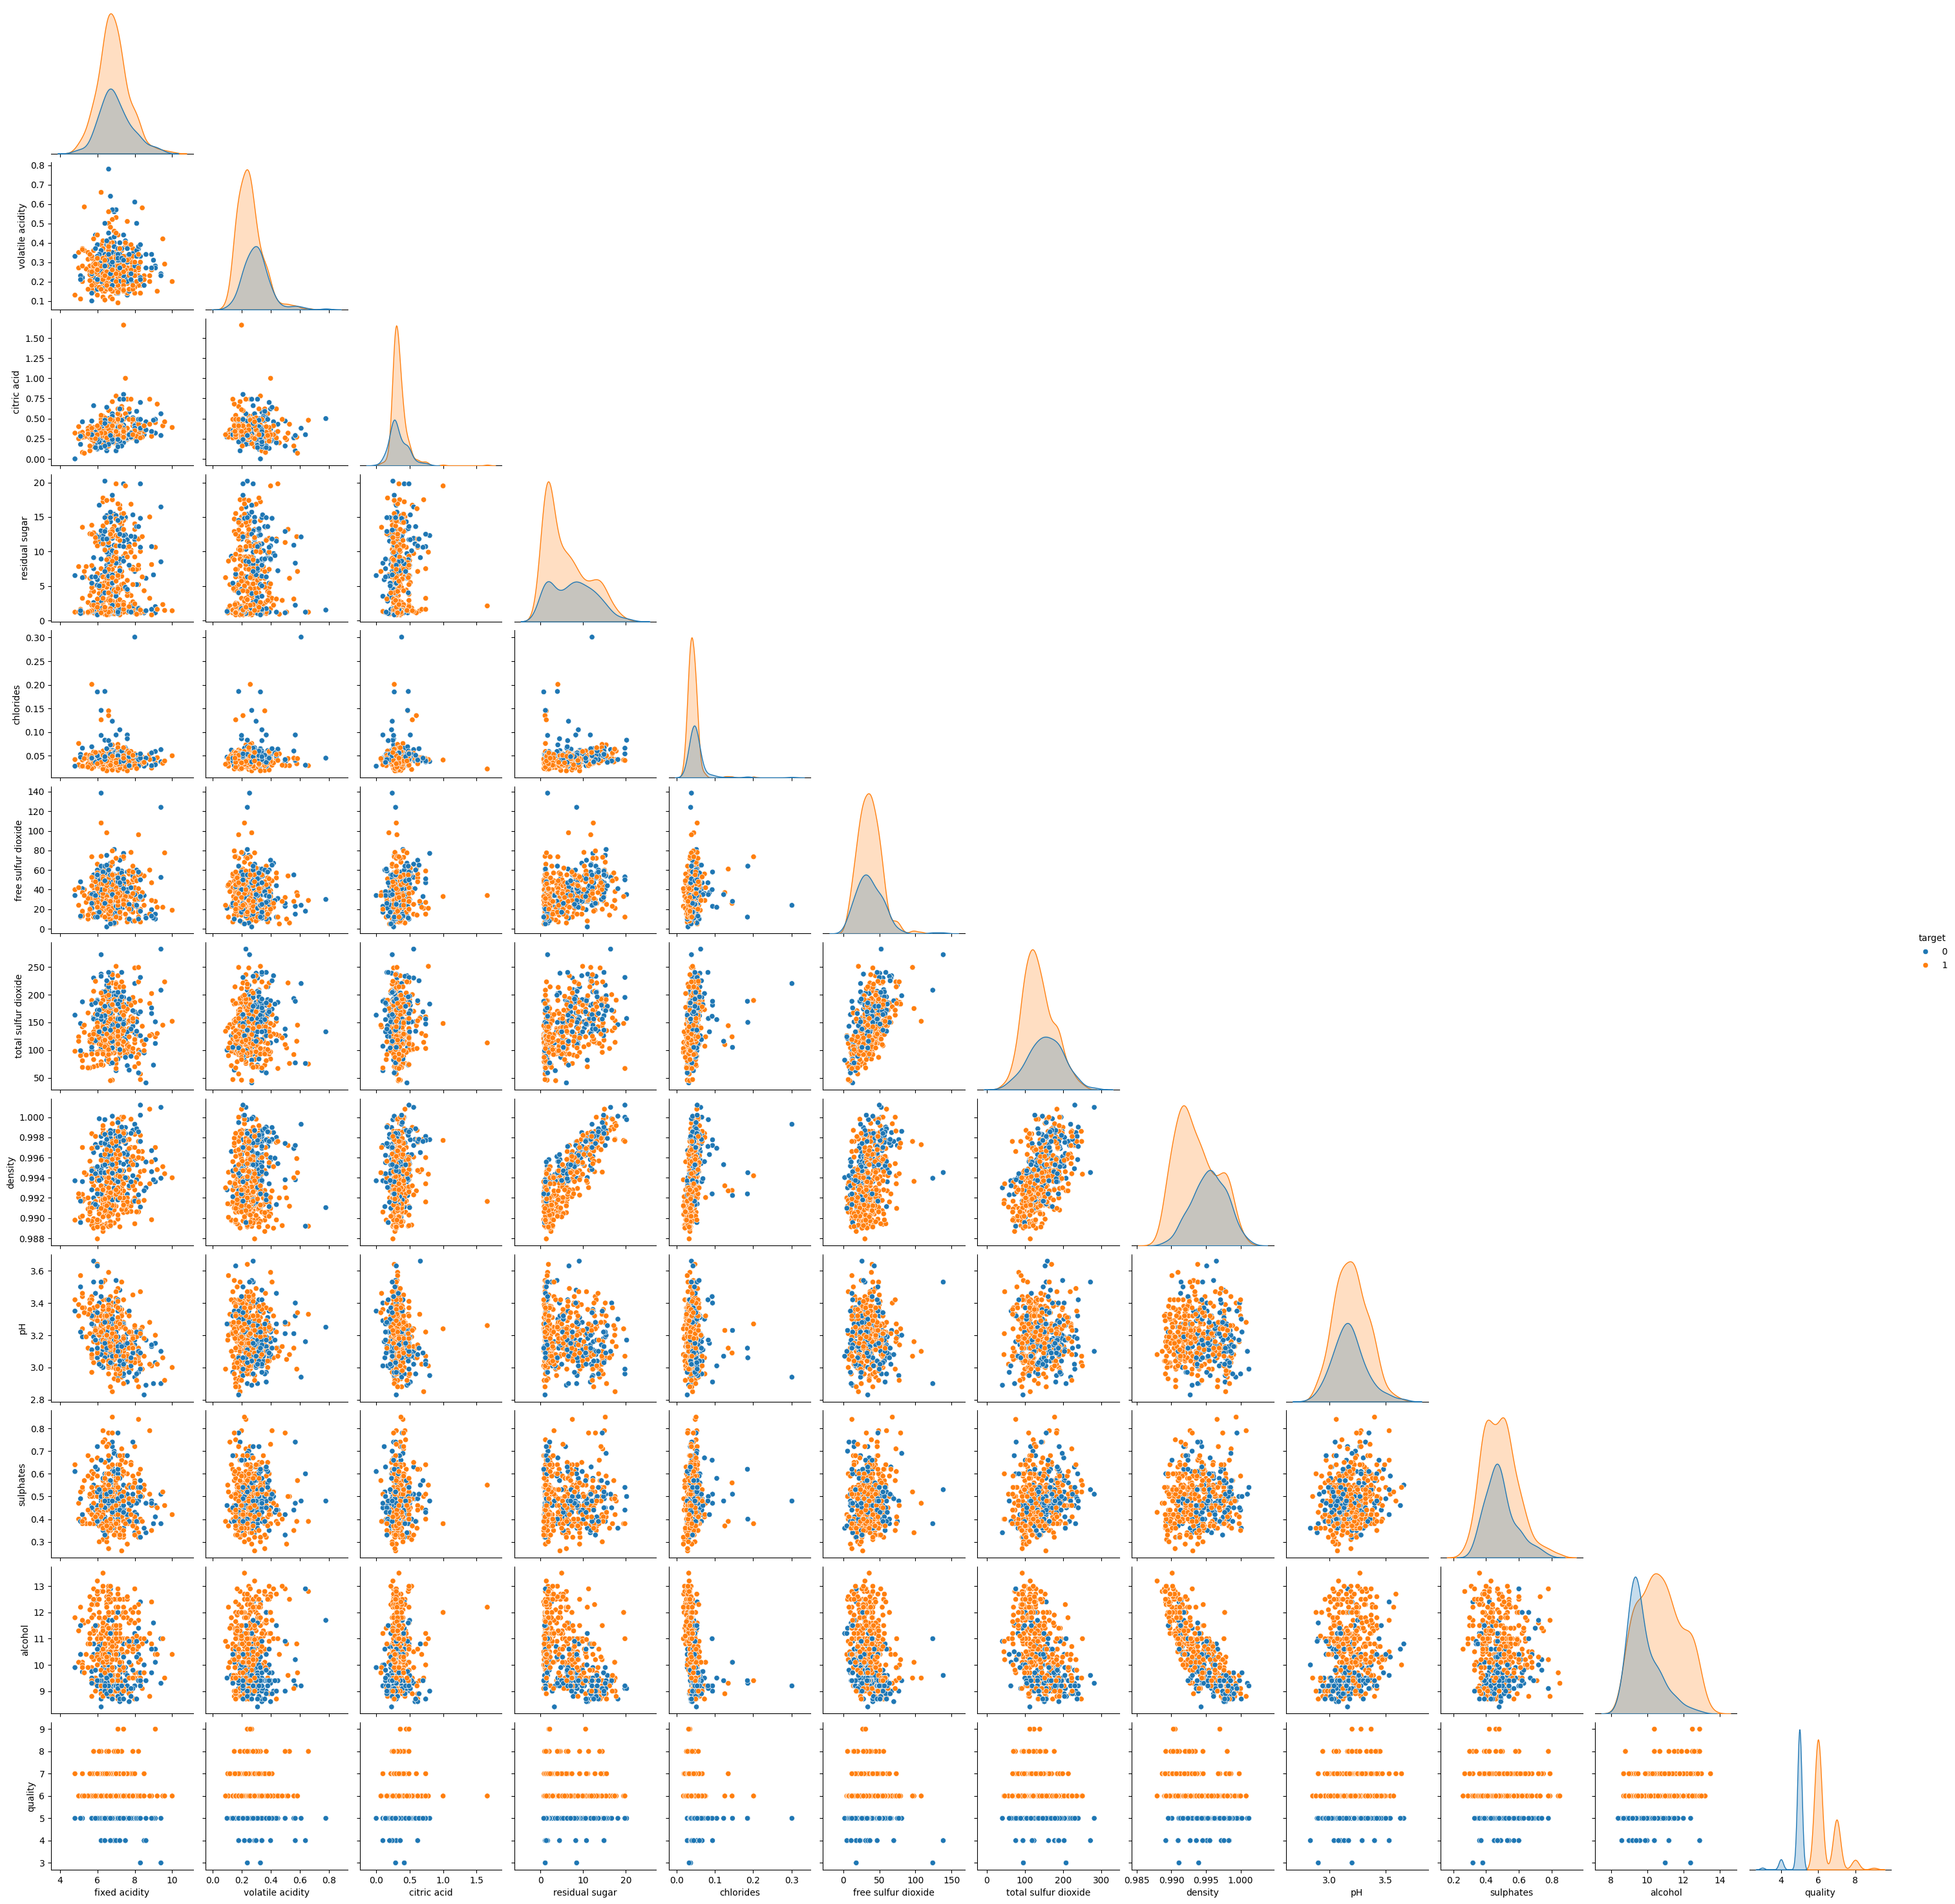

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sample 500 rows for speed
subset = df.sample(n=500, random_state=42)

# Plot only the subset

sns.pairplot(subset, hue='target', corner=True)
plt.show()

In [16]:
# your code here
df = df.drop(['density', 'quality'], axis=1, errors='ignore')

# Verify the remaining columns
print(df.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'pH',
       'sulphates', 'alcohol', 'target'],
      dtype='object')


In [17]:
def partition(X, y, t):
    """
    Input:
        X: numpy array of shape (n_samples, n_features)
        y: numpy array of shape (n_samples,)
        t: float in (0, 1), proportion of data to use as the test set
    Output:
        X_train: numpy array
        X_test: numpy array
        y_train: numpy array
        y_test: numpy array
    """
    # your code
    n_samples = X.shape[0]
    test_size = int(n_samples * t)
    
    # Test set gets the first 'test_size' rows 
    # Train set gets the rest
    X_test = X[:test_size]
    y_test = y[:test_size]
    
    X_train = X[test_size:]
    y_train = y[test_size:]
    return X_train, X_test, y_train, y_test


In [20]:
# Note: This assumes you have X_train, Y_train, X_test, and Y_test 
# ready from your partition function in Question 6.

X = df.drop('quality', axis=1).values

# 2. Define y by isolating just the 'quality' column.
# Again, .values converts it to a NumPy array.
y = df['quality'].values

# Initialize your custom classifier
knn = KNN_Classifier()
X_train, X_test, Y_train, Y_test = partition(X, Y, t=0.2)

# --- 7(a): Unscaled Data ---
# Fit the model using k=5, Euclidean distance, and uniform weights
knn.fit(X_train, Y_train, n_neighbors=5, distance='euclidean', weights='uniform')

# Make predictions on the test set
y_pred_unscaled = knn.predict(X_test)

# Calculate accuracy and F1 score (replace with your actual function names from Part A)
acc_unscaled = calculate_accuracy(Y_test, y_pred_unscaled)
f1_unscaled = calculate_f1_score(Y_test, y_pred_unscaled)

print(f"Unscaled Data - Accuracy: {acc_unscaled:.4f}, F1 Score: {f1_unscaled:.4f}")


# --- 7(b): Standardize the Data ---
# Calculate the mean and standard deviation from the TRAINING set only
train_mean = np.mean(X_train, axis=0)
train_std = np.std(X_train, axis=0)

# Scale both training and test sets using those training statistics
X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std


# --- 7(c): Standardized Data ---
# Re-run the model using the scaled data
knn.fit(X_train_scaled, Y_train, n_neighbors=5, distance='euclidean', weights='uniform')
y_pred_scaled = knn.predict(X_test_scaled)

acc_scaled = calculate_accuracy(Y_test, y_pred_scaled)
f1_scaled = calculate_f1_score(Y_test, y_pred_scaled)

print(f"Standardized Data - Accuracy: {acc_scaled:.4f}, F1 Score: {f1_scaled:.4f}")


# --- 7(e): Inverse Distance Weighting ---
# Re-run the model on the scaled data, but change weights to 'distance'
knn.fit(X_train_scaled, Y_train, n_neighbors=5, distance='euclidean', weights='distance')
y_pred_weighted = knn.predict(X_test_scaled)

acc_weighted = calculate_accuracy(Y_test, y_pred_weighted)
f1_weighted = calculate_f1_score(Y_test, y_pred_weighted)

print(f"Distance Weighted Data - Accuracy: {acc_weighted:.4f}, F1 Score: {f1_weighted:.4f}")

KeyError: "['quality'] not found in axis"